In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

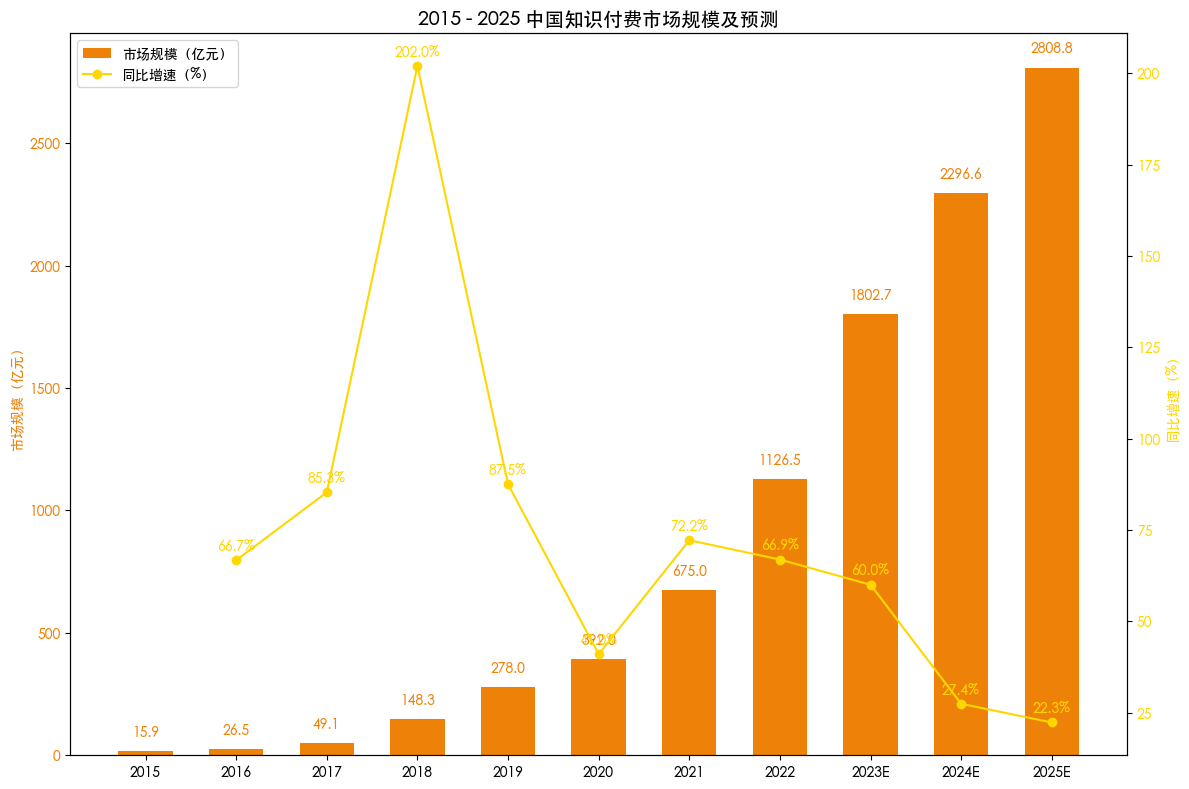

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
years = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023E", "2024E", "2025E"]
market_size = [15.9, 26.5, 49.1, 148.3, 278.0, 392.0, 675.0, 1126.5, 1802.7, 2296.6, 2808.8]  # 市场规模（亿元）
yoy_growth = [66.7, 85.3, 202.0, 87.5, 41.0, 72.2, 66.9, 60.0, 27.4, 22.3]  # 同比增速（%），注意与 years 对应，2015 年无同比（或可根据需求调整），这里从 2016 开始有增速数据，与图表逻辑对齐

x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12, 8))

# 绘制左侧 y 轴（市场规模，柱状图）
ax1.bar(x, market_size, color="#ee8208", width=0.6, label="市场规模（亿元）")
ax1.set_ylabel("市场规模（亿元）", color="#ee8208")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.tick_params(axis="y", labelcolor="#ee8208")

# 创建右侧 y 轴（同比增速，折线图）
ax2 = ax1.twinx()
ax2.plot(x[1:], yoy_growth, color="#ffd700", marker="o", label="同比增速（%）")  # 从 2016 年开始绘制折线，对应 x[1:]
ax2.set_ylabel("同比增速（%）", color="#ffd700")
ax2.tick_params(axis="y", labelcolor="#ffd700")

# 添加市场规模数值标注（柱状图上）
for i, size in enumerate(market_size):
    ax1.text(x[i], size + 50, f'{size}', ha="center", va="bottom", color="#ee8208")

# 添加同比增速数值标注（折线上的点）
for i, growth in enumerate(yoy_growth):
    ax2.text(x[i + 1], growth + 2, f'{growth}%', ha="center", va="bottom", color="#ffd700")  # 对应 x[1:] ，所以索引 +1

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

ax1.set_title("2015 - 2025 中国知识付费市场规模及预测", fontsize=14)
plt.tight_layout()
plt.show()

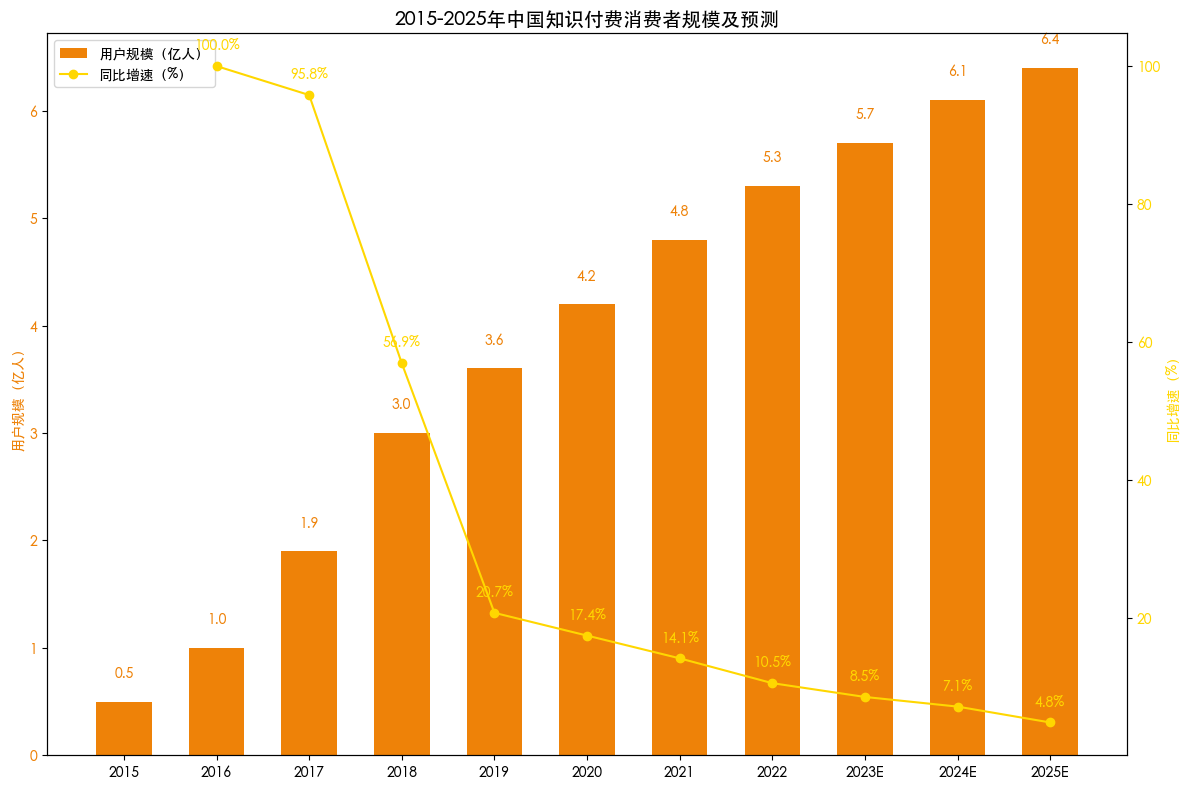

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
years = ["2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023E", "2024E", "2025E"]
user_scale = [0.5, 1.0, 1.9, 3.0, 3.6, 4.2, 4.8, 5.3, 5.7, 6.1, 6.4]  # 用户规模（亿人）
yoy_growth = [100.0, 95.8, 56.9, 20.7, 17.4, 14.1, 10.5, 8.5, 7.1, 4.8]  # 同比增速（%），注意 2015 年无同比（或按逻辑 2016 年增速对应 2015-2016 变化，这里与图表数据对齐）

x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12, 8))

# 绘制左侧 y 轴（用户规模，柱状图）
ax1.bar(x, user_scale, color="#ee8208", width=0.6, label="用户规模（亿人）")
ax1.set_ylabel("用户规模（亿人）", color="#ee8208")
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.tick_params(axis="y", labelcolor="#ee8208")

# 创建右侧 y 轴（同比增速，折线图）
ax2 = ax1.twinx()
ax2.plot(x[1:], yoy_growth, color="#ffd700", marker="o", label="同比增速（%）")  # 增速从 2016 年（x[1:]）开始对应数据
ax2.set_ylabel("同比增速（%）", color="#ffd700")
ax2.tick_params(axis="y", labelcolor="#ffd700")

# 添加用户规模数值标注（柱状图上）
for i, scale in enumerate(user_scale):
    ax1.text(x[i], scale + 0.2, f'{scale}', ha="center", va="bottom", color="#ee8208")

# 添加同比增速数值标注（折线上的点）
for i, growth in enumerate(yoy_growth):
    ax2.text(x[i + 1], growth + 2, f'{growth}%', ha="center", va="bottom", color="#ffd700")  # 对应 x[1:] ，索引 +1 对齐

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

ax1.set_title("2015-2025年中国知识付费消费者规模及预测", fontsize=14)
plt.tight_layout()
plt.show()

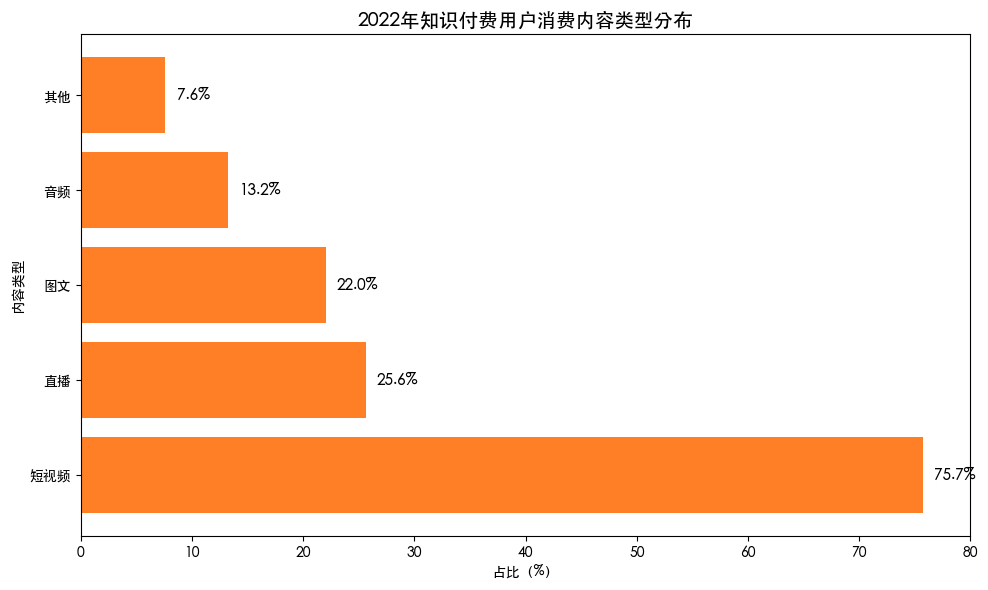

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
content_types = ["短视频", "直播", "图文", "音频", "其他"]
proportions = [75.7, 25.6, 22.0, 13.2, 7.6]  # 占比（%）
colors = ["#ff7f27"]  # 橙色，贴近原图配色

x = np.arange(len(content_types))

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制横向柱状图
bars = ax.barh(x, proportions, color=colors * len(content_types))
ax.set_title('2022年知识付费用户消费内容类型分布', fontsize=14)
ax.set_xlabel('占比（%）')
ax.set_ylabel('内容类型')
ax.set_yticks(x)
ax.set_yticklabels(content_types)
ax.set_xlim(0, 80)  # 调整 x 轴范围，适配最大占比（75.7%）

# 添加数值标注
for i, prop in enumerate(proportions):
    ax.text(prop + 1, i, f'{prop}%', ha='left', va='center', color='black', fontsize=11)

plt.tight_layout()
plt.show()